You’ll need 4 variations:
* Custom networks (at least 3) to show that you explored hyperparameters a bit.
* Transfer learning (at least 2, e.g., VGG, ResNet).
* Data augmentation with custom network (only 1 network is enough, the one that previously gave the best results).
* Data augmentation with transfer learning (the above 2+ networks).

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
import kagglehub
import os
from PIL import Image
import imageio

# Import Data

In [2]:


path = kagglehub.dataset_download("luisolazo/tomato-diseases")


print("Path to dataset files:", path)


100%|██████████| 411M/411M [00:02<00:00, 156MB/s]

Extracting files...


Path to dataset files: /root/.cache/kagglehub/datasets/luisolazo/tomato-diseases/versions/3


In [3]:
dataset_path = path

In [4]:

print(os.listdir(dataset_path))

['train', 'test']


In [5]:
labels=os.listdir(dataset_path+'/train')
print(labels)

['healthy', 'bacterial_spot', 'early_blight', 'mosaic_virus', 'twospotted_spider_mite', 'leaf_mold', 'late_blight', 'septoria_leaf_spot', 'yellow_leaf_curl_virus', 'target_spot']


# Data Preprocessing

In [6]:
test_labels=os.listdir(dataset_path+'/test')

In [7]:
for label in labels:
  print(label,len(os.listdir(dataset_path+'/train/'+label)))

healthy 1883
bacterial_spot 1679
early_blight 2177
mosaic_virus 1197
twospotted_spider_mite 1232
leaf_mold 1460
late_blight 2093
septoria_leaf_spot 1327
yellow_leaf_curl_virus 3595
target_spot 1110


In [8]:
for label in labels:
  print(f"The {label} has, {len(os.listdir(dataset_path+'/train/'+label))} samples in the train folder")

The healthy has, 1883 samples in the train folder
The bacterial_spot has, 1679 samples in the train folder
The early_blight has, 2177 samples in the train folder
The mosaic_virus has, 1197 samples in the train folder
The twospotted_spider_mite has, 1232 samples in the train folder
The leaf_mold has, 1460 samples in the train folder
The late_blight has, 2093 samples in the train folder
The septoria_leaf_spot has, 1327 samples in the train folder
The yellow_leaf_curl_virus has, 3595 samples in the train folder
The target_spot has, 1110 samples in the train folder


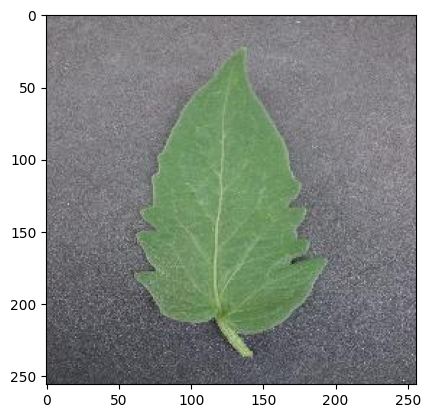

In [9]:
path_of=os.listdir(dataset_path+'/train/healthy')
image=plt.imread(dataset_path+'/train/healthy/'+path_of[1])
plt.imshow(image)

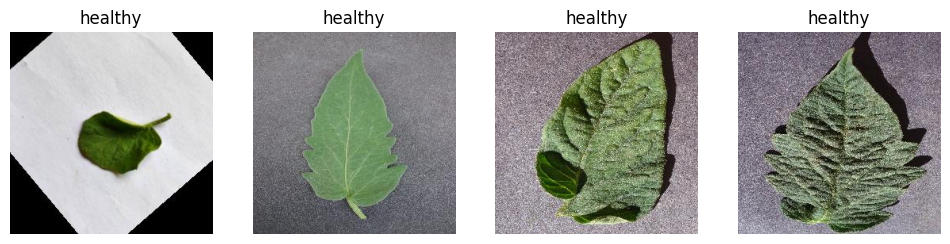

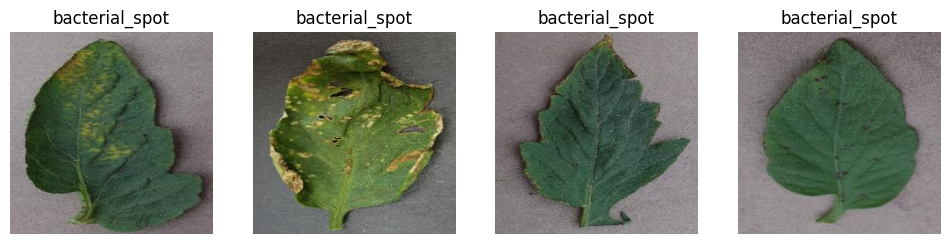

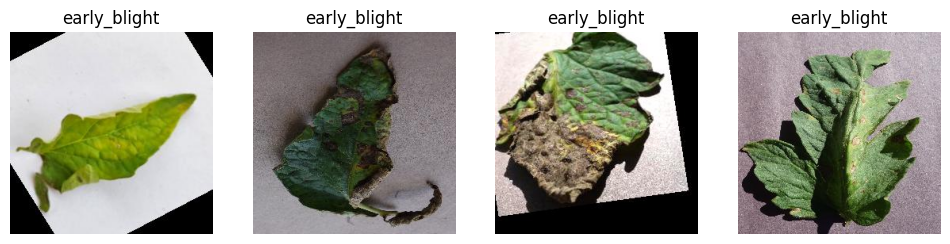

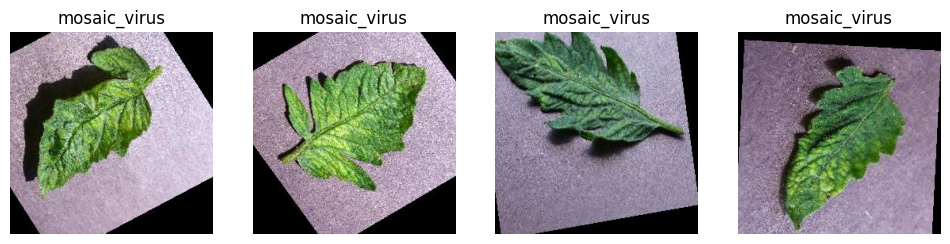

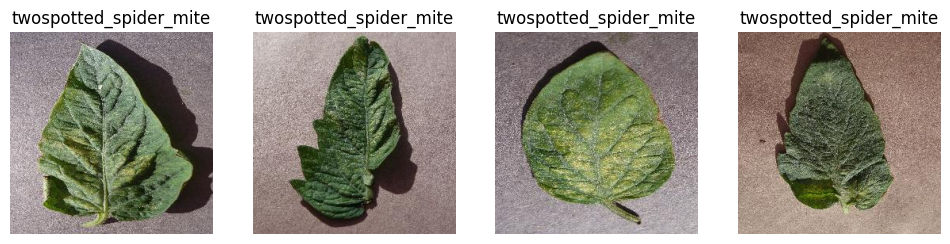

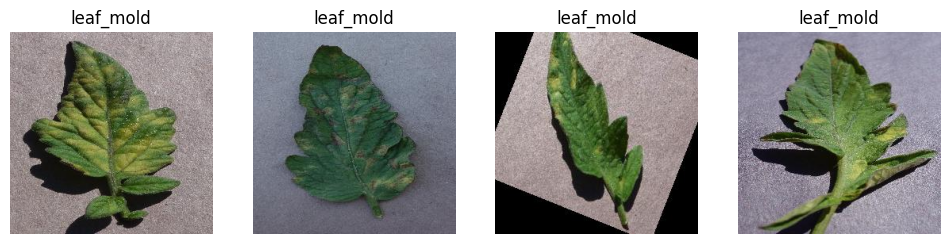

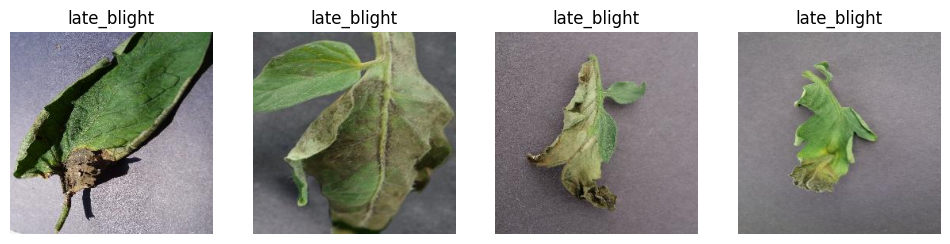

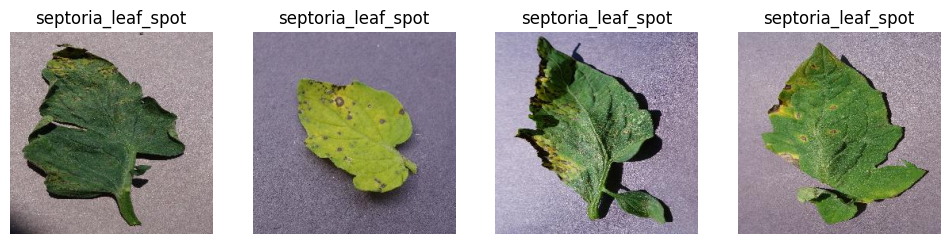

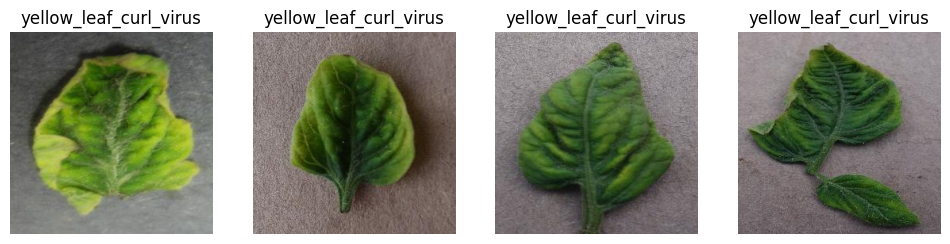

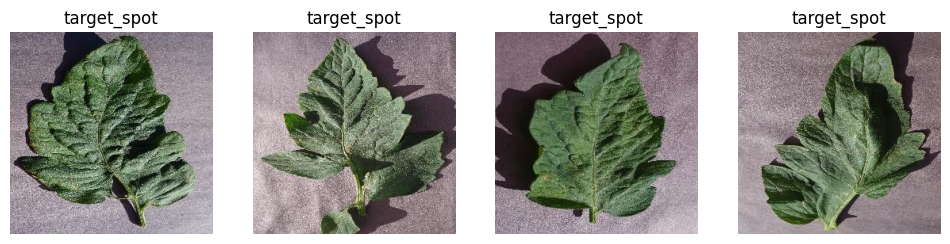

In [10]:
for label in labels:
    fig, axes = plt.subplots(1, 4, figsize=(12, 4))

    path_of_images = os.listdir(os.path.join(dataset_path, 'train', label))[:4]

    for i, image_name in enumerate(path_of_images):
        image_path = os.path.join(dataset_path, 'train', label, image_name)
        image = plt.imread(image_path)

        axes[i].imshow(image)
        axes[i].axis('off')
        axes[i].set_title(label)

    plt.show()

In [11]:
train_data,validation_data=tf.keras.preprocessing.image_dataset_from_directory(directory=dataset_path+'/train',
                                                               image_size=(255,255),batch_size=32,
                                                               label_mode='categorical',shuffle=True,
                                                              validation_split=0.2,subset='both',seed=1)

Found 17753 files belonging to 10 classes.
Using 14203 files for training.
Using 3550 files for validation.


In [12]:
train_data=train_data.map(lambda x,y:(x/255,y) )
validation_data=validation_data.map(lambda x,y:(x/255,y) )

In [13]:
test_data=tf.keras.preprocessing.image_dataset_from_directory(directory=dataset_path+'/test',
                                                              image_size=(255,255),batch_size=32,
                                                              label_mode='categorical')

Found 4440 files belonging to 10 classes.


In [14]:
test_data=test_data.map(lambda x,y:(x/255,y))

In [15]:
for image,target in train_data.take(1):
  print(target)

tf.Tensor(
[[0. 1. 0. 0. 0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 1. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0. 0. 0. 0. 0. 1.]
 [0. 0. 0. 0. 0. 0. 0. 0. 1. 0.]
 [0. 0. 0. 0. 0. 0. 0. 0. 0. 1.]
 [0. 0. 1. 0. 0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0. 0. 0. 0. 0. 1.]
 [0. 0. 0. 1. 0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0. 0. 0. 0. 0. 1.]
 [0. 0. 0. 0. 0. 0. 0. 0. 0. 1.]
 [0. 0. 0. 0. 0. 1. 0. 0. 0. 0.]
 [0. 0. 0. 1. 0. 0. 0. 0. 0. 0.]
 [1. 0. 0. 0. 0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0. 0. 1. 0. 0. 0.]
 [0. 0. 0. 1. 0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0. 1. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0. 0. 0. 0. 0. 1.]
 [0. 0. 0. 0. 0. 1. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0. 0. 0. 0. 0. 1.]
 [0. 0. 0. 0. 0. 0. 0. 0. 0. 1.]
 [0. 0. 0. 0. 0. 0. 1. 0. 0. 0.]
 [0. 1. 0. 0. 0. 0. 0. 0. 0. 0.]
 [0. 0. 1. 0. 0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0. 0. 1. 0. 0. 0.]
 [0. 0. 0. 0. 1. 0. 0. 0. 0. 0.]
 [0. 0. 1. 0. 0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 1. 0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0. 0. 0. 0. 1. 0.]
 [0. 0. 0. 0. 0. 0. 0. 0. 0. 1.]
 [1. 0. 0. 0. 0. 0. 0. 0. 0. 0.]

# Train Our Models

# Model_1

In [16]:
from functools import partial
Conv2d=partial(tf.keras.layers.Conv2D,kernel_size=3,padding='same',strides=1 )

@tf.keras.utils.register_keras_serializable()
class Inception_mode(tf.keras.layers.Layer):
  def __init__ (self,filters,strides=1,activation='relu',**kwargs):
    super().__init__(**kwargs)
    self.filters=filters
    self.strides=strides
    self.activation=activation
    self.concat = tf.keras.layers.Concatenate(axis=-1)

    self.inception_layers_1=[tf.keras.layers.MaxPooling2D(pool_size=2,strides=strides,padding='same'),
                             Conv2d(filters=filters,activation=activation),
                             tf.keras.layers.BatchNormalization(),
                             Conv2d(filters=filters)]

    self.inception_layers_2=[tf.keras.layers.AveragePooling2D(pool_size=2,strides=strides,padding='same'),
                             Conv2d(filters=filters),
                             tf.keras.layers.BatchNormalization(),
                             Conv2d(filters=filters)]

    self.inception_layers_3=[Conv2d(filters=filters,strides=strides,activation=activation,kernel_size=1),
                             tf.keras.layers.BatchNormalization(),
                             Conv2d(filters=filters,kernel_size=1)]



  def build(self, input_shape):
      input_shape = list(input_shape)
      input_shape[0] = 1
      input_shape = tuple(input_shape)

      dummy = tf.keras.backend.zeros(input_shape)
      _ = self.call(dummy)
      super().build(input_shape)


  def call(self, inputs):
      def apply_layers(x, layer_list):
          for layer in layer_list:
              x = layer(x)
          return x

      x1 = apply_layers(inputs, self.inception_layers_1)
      x2 = apply_layers(inputs, self.inception_layers_2)
      x3 = apply_layers(inputs, self.inception_layers_3)

      return self.concat([x1, x2, x3])

  def get_config(self):
    config = super().get_config()
    config.update({
        "filters": self.filters,
        "strides": self.strides,
        "activation": self.activation
    })
    return config

In [ ]:
inputs=tf.keras.layers.Input(shape=(255,255,3))
layer_2=tf.keras.layers.Conv2D(filters=32,kernel_size=2,padding='same',activation='relu')(inputs)
layer_3=Inception_mode(filters=32)(layer_2)
max_0=tf.keras.layers.MaxPool2D(pool_size=(2,2))(layer_3)
layer_4=tf.keras.layers.Conv2D(filters=64,kernel_size=2,padding='same',activation='relu')(max_0)
layer_5=Inception_mode(filters=64)(layer_4)
concatlayer_1=tf.keras.layers.Concatenate(axis=-1)([layer_4,layer_5])
max_1=tf.keras.layers.MaxPool2D(pool_size=(2,2))(concatlayer_1)
normal=tf.keras.layers.BatchNormalization()(max_1)
layer_6=tf.keras.layers.Conv2D(filters=128,kernel_size=3,padding='same',activation='relu')(normal)
layer_7=Inception_mode(filters=128)(layer_6)
layer_8=tf.keras.layers.Conv2D(filters=256,kernel_size=3,padding='same',activation='relu')(layer_7)
layer_9=Inception_mode(filters=256)(layer_8)
concatlayer_2=tf.keras.layers.Concatenate(axis=-1)([layer_6,layer_9])
max_2=tf.keras.layers.MaxPool2D(pool_size=(2,2))(concatlayer_2)
layer_10=tf.keras.layers.GlobalAveragePooling2D()(max_2)
outputs=tf.keras.layers.Dense(10,activation='softmax')(layer_10)

model_1=tf.keras.Model(inputs=inputs,outputs=outputs)








model_1.summary()
model_1.compile(optimizer=tf.keras.optimizers.SGD(momentum=0.9,nesterov=True),loss='categorical_crossentropy',metrics=['accuracy'])

Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_1       │ (None, 255, 255,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_28 (Conv2D)  │ (None, 255, 255,  │        416 │ input_layer_1[0]… │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ inception_mode_4    │ (None, 255, 255,  │     39,488 │ conv2d_28[0][0]   │
│ (Inception_mode)    │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_7     │ (None, 127, 127,  │          0 │ inception_mode_4… │
│ (MaxPooling2D)      │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_35 (Conv2D)  │ (None, 127, 127,  │     24,640 │ max_pooling2d_7[… │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ inception_mode_5    │ (None, 127, 127,  │    156,800 │ conv2d_35[0][0]   │
│ (Inception_mode)    │ 192)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate_8       │ (None, 127, 127,  │          0 │ conv2d_35[0][0],  │
│ (Concatenate)       │ 256)              │            │ inception_mode_5… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_9     │ (None, 63, 63,    │          0 │ concatenate_8[0]… │
│ (MaxPooling2D)      │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 63, 63,    │      1,024 │ max_pooling2d_9[… │
│ (BatchNormalizatio… │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_42 (Conv2D)  │ (None, 63, 63,    │    295,040 │ batch_normalizat… │
│                     │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ inception_mode_6    │ (None, 63, 63,    │    624,896 │ conv2d_42[0][0]   │
│ (Inception_mode)    │ 384)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_49 (Conv2D)  │ (None, 63, 63,    │    884,992 │ inception_mode_6… │
│                     │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ inception_mode_7    │ (None, 63, 63,    │  2,494,976 │ conv2d_49[0][0]   │
│ (Inception_mode)    │ 768)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate_11      │ (None, 63, 63,    │          0 │ conv2d_42[0][0],  │
│ (Concatenate)       │ 896)              │            │ inception_mode_7… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_12    │ (None, 31, 31,    │          0 │ concatenate_11[0… │
│ (MaxPooling2D)      │ 896)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ global_average_poo… │ (None, 896)       │          0 │ max_pooling2d_12… │
│ (GlobalAveragePool… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_1 (Dense)     │ (None, 10)        │      8,970 │ global_average_p

 Total params: 4,531,242 (17.29 MB)

 Trainable params: 4,527,850 (17.27 MB)

 Non-trainable params: 3,392 (13.25 KB)

In [ ]:



def lr_schedule_exp(epoch):
  if epoch<15:
    return float(tf.exp(-epoch/10.)*0.01)/2
  else:
    return 0.0001/5
schedule_1=tf.keras.callbacks.LearningRateScheduler(lr_schedule_exp)
check_point_1=tf.keras.callbacks.ModelCheckpoint('model_1.keras',monitor='val_accuracy',verbose=1,save_best_only=True)

In [ ]:
history_1=model_1.fit(train_data,epochs=20,validation_data=(validation_data),callbacks=[schedule_1,check_point_1])

Epoch 1/20
444/444 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.6720 - loss: 0.9516
Epoch 1: val_accuracy improved from -inf to 0.45634, saving model to model_1.keras
444/444 ━━━━━━━━━━━━━━━━━━━━ 636s 1s/step - accuracy: 0.6722 - loss: 0.9510 - val_accuracy: 0.4563 - val_loss: 1.8831 - learning_rate: 0.0050
Epoch 2/20
444/444 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.8572 - loss: 0.4293
Epoch 2: val_accuracy improved from 0.45634 to 0.54056, saving model to model_1.keras
444/444 ━━━━━━━━━━━━━━━━━━━━ 492s 1s/step - accuracy: 0.8572 - loss: 0.4293 - val_accuracy: 0.5406 - val_loss: 1.7817 - learning_rate: 0.0045
Epoch 3/20
444/444 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.9003 - loss: 0.2868
Epoch 3: val_accuracy improved from 0.54056 to 0.86704, saving model to model_1.keras
444/444 ━━━━━━━━━━━━━━━━━━━━ 491s 1s/step - accuracy: 0.9003 - loss: 0.2867 - val_accuracy: 0.8670 - val_loss: 0.3910 - learning_rate: 0.0041
Epoch 4/20
444/444 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0

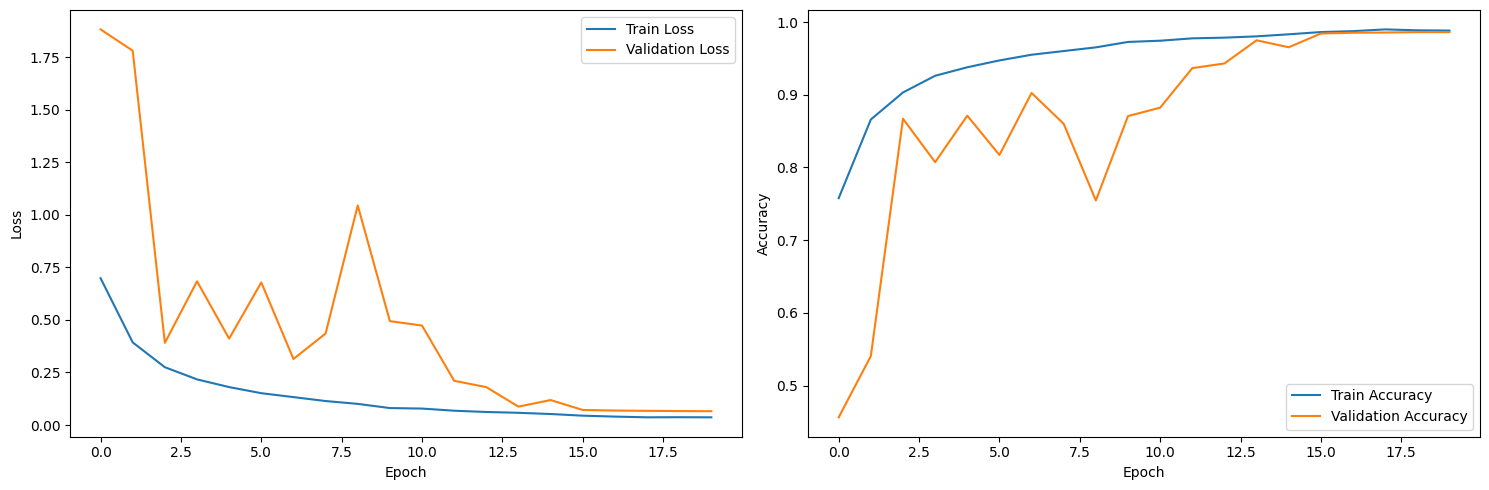

In [ ]:
fig,axes=plt.subplots(1,2,figsize=(15,5))

axes[0].plot(history_1.history['loss'],label='Train Loss')
axes[0].plot(history_1.history['val_loss'],label='Validation Loss')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Loss')
axes[0].legend()

axes[1].plot(history_1.history['accuracy'],label='Train Accuracy')
axes[1].plot(history_1.history['val_accuracy'],label='Validation Accuracy')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Accuracy')
axes[1].legend()

plt.tight_layout()

In [ ]:
model_1.evaluate(test_data)

139/139 ━━━━━━━━━━━━━━━━━━━━ 63s 452ms/step - accuracy: 0.9876 - loss: 0.0372


[0.04232509434223175, 0.9842342138290405]

In [ ]:
model_1.save('model_1_Tomato_(98.52).keras')

# Model_2

In [ ]:
@tf.keras.utils.register_keras_serializable()
class Recalibration_block(tf.keras.layers.Layer):
  def __init__(self,filters,activation='relu',**kwargs):
    super().__init__(**kwargs)
    self.filters=filters
    self.activation=activation

    self.block=[tf.keras.layers.GlobalAveragePooling2D(),
                tf.keras.layers.Dense(units=filters//16,activation=activation),
                tf.keras.layers.Dense(units=filters,activation='sigmoid'),
                tf.keras.layers.Reshape((1,1,filters))]

  def call(self,inputs):
    x=inputs
    for layer in self.block:
      x=layer(x)
    out=tf.multiply(inputs,x)
    return out

  def get_config(self):
    config = super().get_config()
    config.update({
        "filters": self.filters,
        "activation": self.activation
    })
    return config



inputs=tf.keras.layers.Input(shape=(255,255,3))
max_1=tf.keras.layers.MaxPool2D(pool_size=(3,3))(inputs)
layer_2=tf.keras.layers.Conv2D(filters=32,kernel_size=2,padding='same',activation='relu')(max_1)
layer_3=Inception_mode(filters=32)(layer_2)
layer_4=tf.keras.layers.SeparableConv2D(filters=64,kernel_size=2,padding='same',activation='relu')(layer_3)
layer_5=Inception_mode(filters=64)(layer_4)
recal_0=Recalibration_block(filters=layer_5.shape[-1])(layer_5)
concatlayer_1=tf.keras.layers.Concatenate(axis=-1)([layer_2,recal_0,layer_5])
normal=tf.keras.layers.BatchNormalization()(concatlayer_1)
layer_6=tf.keras.layers.SeparableConv2D(filters=128,kernel_size=3,padding='same',activation='relu')(normal)
layer_7=Inception_mode(filters=128)(layer_6)
layer_8=tf.keras.layers.SeparableConv2D(filters=256,kernel_size=3,padding='same',activation='relu')(layer_7)
layer_9=Inception_mode(filters=256)(layer_8)
recal_1=Recalibration_block(filters=layer_9.shape[-1])(layer_9)
concatlayer_2=tf.keras.layers.Concatenate(axis=-1)([layer_8,recal_1,layer_9])
layer_10=tf.keras.layers.GlobalAveragePooling2D()(recal_1)
outputs=tf.keras.layers.Dense(10,activation='softmax')(layer_10)

model_2=tf.keras.Model(inputs=inputs,outputs=outputs)
model_2.summary()
model_2.compile(optimizer=tf.keras.optimizers.SGD(momentum=0.9,nesterov=True),loss='categorical_crossentropy',metrics=['accuracy'])

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_2       │ (None, 255, 255,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_10    │ (None, 85, 85, 3) │          0 │ input_layer_2[0]… │
│ (MaxPooling2D)      │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_50 (Conv2D)  │ (None, 85, 85,    │        416 │ max_pooling2d_10… │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ inception_mode_8    │ (None, 85, 85,    │     39,488 │ conv2d_50[0][0]   │
│ (Inception_mode)    │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ separable_conv2d_6  │ (None, 85, 85,    │      6,592 │ inception_mode_8… │
│ (SeparableConv2D)   │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ inception_mode_9    │ (None, 85, 85,    │    156,800 │ separable_conv2d… │
│ (Inception_mode)    │ 192)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ recalibration_bloc… │ (None, 85, 85,    │      4,812 │ inception_mode_9… │
│ (Recalibration_blo… │ 192)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate_14      │ (None, 85, 85,    │          0 │ conv2d_50[0][0],  │
│ (Concatenate)       │ 416)              │            │ recalibration_bl… │
│                     │                   │            │ inception_mode_9… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 85, 85,    │      1,664 │ concatenate_14[0… │
│ (BatchNormalizatio… │ 416)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ separable_conv2d_7  │ (None, 85, 85,    │     57,120 │ batch_normalizat… │
│ (SeparableConv2D)   │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ inception_mode_10   │ (None, 85, 85,    │    624,896 │ separable_conv2d… │
│ (Inception_mode)    │ 384)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ separable_conv2d_8  │ (None, 85, 85,    │    102,016 │ inception_mode_1… │
│ (SeparableConv2D)   │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ inception_mode_11   │ (None, 85, 85,    │  2,494,976 │ separable_conv2d… │
│ (Inception_mode)    │ 768)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ recalibration_bloc… │ (None, 85, 85,    │     74,544 │ inception_mode_1… │
│ (Recalibration_blo… │ 768)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ global_average_poo… │ (None, 768)       │          0 │ recalibration_bl… │
│ (GlobalAveragePool… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_14 (Dense)    │ (None, 10)        │      7,690 │ global_average_p… │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 3,571,014 (13.62 MB)

 Trainable params: 3,567,302 (13.61 MB)

 Non-trainable params: 3,712 (14.50 KB)

In [ ]:
def lr_schedule_exp(epoch):
  if epoch<15:
    return float(tf.exp(-epoch/10.)*0.01)/2
  else:
    return 0.0001/4
schedule_1=tf.keras.callbacks.LearningRateScheduler(lr_schedule_exp)
check_point_1=tf.keras.callbacks.ModelCheckpoint('model_2.keras',monitor='val_accuracy',verbose=1,save_best_only=True)

In [ ]:
history_2=model_2.fit(train_data,epochs=20,validation_data=(validation_data),callbacks=[schedule_1,check_point_1])

Epoch 1/20
444/444 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.6374 - loss: 1.0643   
Epoch 1: val_accuracy improved from -inf to 0.28620, saving model to model_2.keras
444/444 ━━━━━━━━━━━━━━━━━━━━ 571s 1s/step - accuracy: 0.6377 - loss: 1.0637 - val_accuracy: 0.2862 - val_loss: 3.1905 - learning_rate: 0.0050
Epoch 2/20
444/444 ━━━━━━━━━━━━━━━━━━━━ 0s 917ms/step - accuracy: 0.8434 - loss: 0.4590
Epoch 2: val_accuracy improved from 0.28620 to 0.40592, saving model to model_2.keras
444/444 ━━━━━━━━━━━━━━━━━━━━ 449s 1s/step - accuracy: 0.8434 - loss: 0.4589 - val_accuracy: 0.4059 - val_loss: 3.6999 - learning_rate: 0.0045
Epoch 3/20
444/444 ━━━━━━━━━━━━━━━━━━━━ 0s 920ms/step - accuracy: 0.8883 - loss: 0.3368
Epoch 3: val_accuracy improved from 0.40592 to 0.56789, saving model to model_2.keras
444/444 ━━━━━━━━━━━━━━━━━━━━ 503s 1s/step - accuracy: 0.8883 - loss: 0.3367 - val_accuracy: 0.5679 - val_loss: 1.8940 - learning_rate: 0.0041
Epoch 4/20
444/444 ━━━━━━━━━━━━━━━━━━━━ 0s 920ms/step -

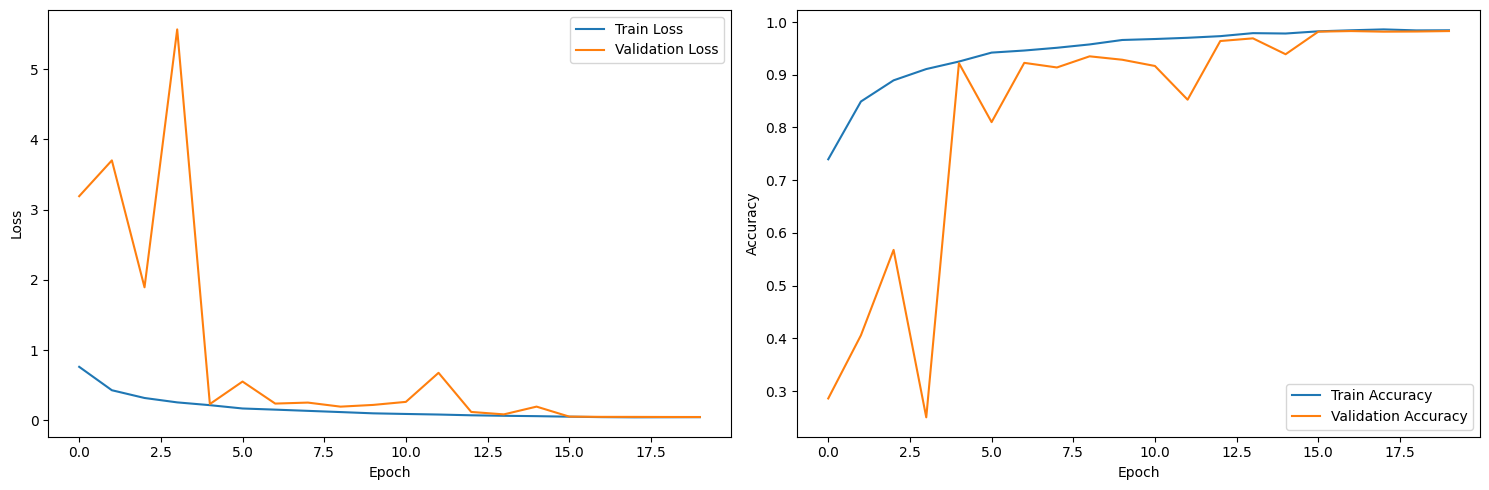

In [ ]:
fig,axes=plt.subplots(1,2,figsize=(15,5))

axes[0].plot(history_2.history['loss'],label='Train Loss')
axes[0].plot(history_2.history['val_loss'],label='Validation Loss')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Loss')
axes[0].legend()

axes[1].plot(history_2.history['accuracy'],label='Train Accuracy')
axes[1].plot(history_2.history['val_accuracy'],label='Validation Accuracy')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Accuracy')
axes[1].legend()

plt.tight_layout()

In [ ]:
model_2.evaluate(test_data)

139/139 ━━━━━━━━━━━━━━━━━━━━ 58s 420ms/step - accuracy: 0.9867 - loss: 0.0449


[0.046786848455667496, 0.9855855703353882]

In [ ]:
model_2.save('Model_2_98.67.keras')

# Model_3

In [ ]:
@tf.keras.utils.register_keras_serializable()
class Recalibration_block(tf.keras.layers.Layer):
  def __init__(self,filters,activation='relu',**kwargs):
    super().__init__(**kwargs)
    self.filters=filters
    self.activation=activation

    self.block=[tf.keras.layers.GlobalAveragePooling2D(),
                tf.keras.layers.Dense(units=filters//16,activation=activation),
                tf.keras.layers.Dense(units=filters,activation='sigmoid'),
                tf.keras.layers.Reshape((1,1,filters))]

  def call(self,inputs):
    x=inputs
    for layer in self.block:
      x=layer(x)
    out=tf.multiply(inputs,x)
    return out

  def get_config(self):
    config = super().get_config()
    config.update({
        "filters": self.filters,
        "activation": self.activation
    })
    return config

from functools import partial
Conv2d=partial(tf.keras.layers.Conv2D,kernel_size=3,padding='same',strides=1 )

@tf.keras.utils.register_keras_serializable()
class Inception_mode(tf.keras.layers.Layer):
  def __init__ (self,filters,strides=1,activation='relu',**kwargs):
    super().__init__(**kwargs)
    self.filters=filters
    self.strides=strides
    self.activation=activation
    self.concat = tf.keras.layers.Concatenate(axis=-1)

    self.inception_layers_1=[tf.keras.layers.MaxPooling2D(pool_size=2,strides=strides,padding='same'),
                             Conv2d(filters=filters,activation=activation),
                             tf.keras.layers.BatchNormalization(),
                             Conv2d(filters=filters)]

    self.inception_layers_2=[tf.keras.layers.AveragePooling2D(pool_size=2,strides=strides,padding='same'),
                             Conv2d(filters=filters),
                             tf.keras.layers.BatchNormalization(),
                             Conv2d(filters=filters)]

    self.inception_layers_3=[Conv2d(filters=filters,strides=strides,activation=activation,kernel_size=1),
                             tf.keras.layers.BatchNormalization(),
                             Conv2d(filters=filters,kernel_size=1)]


    self.inception_layers_4=[Conv2d(filters=filters),
                             Recalibration_block(filters=filters),
                             ]

  def build(self, input_shape):
      input_shape = list(input_shape)
      input_shape[0] = 1
      input_shape = tuple(input_shape)

      dummy = tf.keras.backend.zeros(input_shape)
      _ = self.call(dummy)
      super().build(input_shape)


  def call(self, inputs):
      def apply_layers(x, layer_list):
          for layer in layer_list:
              x = layer(x)
          return x

      x1 = apply_layers(inputs, self.inception_layers_1)
      x2 = apply_layers(inputs, self.inception_layers_2)
      x3 = apply_layers(inputs, self.inception_layers_3)
      x4 = apply_layers(inputs, self.inception_layers_4)
      return self.concat([x1, x2, x3, x4])

  def get_config(self):
    config = super().get_config()
    config.update({
        "filters": self.filters,
        "strides": self.strides,
        "activation": self.activation
    })
    return config

In [ ]:
inputs=tf.keras.layers.Input(shape=(255,255,3))
max_1=tf.keras.layers.MaxPool2D(pool_size=(3,3))(inputs)
layer_1=Inception_mode(filters=32)(max_1)
layer_2=Inception_mode(filters=64)(layer_1)
concatlayer_1=tf.keras.layers.Concatenate(axis=-1)([layer_1,layer_2])
layer_3=Inception_mode(filters=128)(concatlayer_1)
layer_4=Inception_mode(filters=256)(layer_3)
concatlayer_2=tf.keras.layers.Concatenate(axis=-1)([layer_3,layer_4])
layer_5=tf.keras.layers.GlobalAveragePooling2D()(concatlayer_2)
outputs=tf.keras.layers.Dense(10,activation='softmax')(layer_5)

model_3=tf.keras.Model(inputs=inputs,outputs=outputs)








model_3.summary()
model_3.compile(optimizer=tf.keras.optimizers.SGD(momentum=0.9,nesterov=True),loss='categorical_crossentropy',metrics=['accuracy'])

Model: "model"
__________________________________________________________________________________________________
 Layer (type)                   Output Shape         Param #     Connected to                     
 input_1 (InputLayer)           [(None, 255, 255, 3  0           []                               
                                )]                                                                
                                                                                                  
 max_pooling2d (MaxPooling2D)   (None, 85, 85, 3)    0           ['input_1[0][0]']                
                                                                                                  
 inception_mode (Inception_mode  (None, 85, 85, 128)  22914      ['max_pooling2d[0][0]']          
 )                                                                                                
                                                                                              

In [ ]:

def lr_schedule_exp(epoch):
  if epoch<13:
    return float(tf.exp(-epoch/10.)*0.01)/4
  else:
    return 0.0001/3
schedule_3=tf.keras.callbacks.LearningRateScheduler(lr_schedule_exp)
check_point_3=tf.keras.callbacks.ModelCheckpoint('model_3.keras',monitor='val_accuracy',verbose=1,save_best_only=True)

In [ ]:
history_3=model_3.fit(train_data,epochs=20,validation_data=(validation_data),callbacks=[schedule_3,check_point_3])

Epoch 1/20
1776/1776 [==============================] - ETA: 0s - loss: 1.0485 - accuracy: 0.6432
Epoch 1: val_accuracy improved from -inf to 0.72056, saving model to model_3.keras
1776/1776 [==============================] - 695s 383ms/step - loss: 1.0485 - accuracy: 0.6432 - val_loss: 0.8454 - val_accuracy: 0.7206 - lr: 0.0025
Epoch 2/20
1776/1776 [==============================] - ETA: 0s - loss: 0.6500 - accuracy: 0.7738
Epoch 2: val_accuracy did not improve from 0.72056
1776/1776 [==============================] - 671s 378ms/step - loss: 0.6500 - accuracy: 0.7738 - val_loss: 1.8022 - val_accuracy: 0.5530 - lr: 0.0023
Epoch 3/20
1776/1776 [==============================] - ETA: 0s - loss: 0.4905 - accuracy: 0.8331
Epoch 3: val_accuracy improved from 0.72056 to 0.86028, saving model to model_3.keras
1776/1776 [==============================] - 674s 379ms/step - loss: 0.4905 - accuracy: 0.8331 - val_loss: 0.4140 - val_accuracy: 0.8603 - lr: 0.0020
Epoch 4/20
1776/1776 [==============

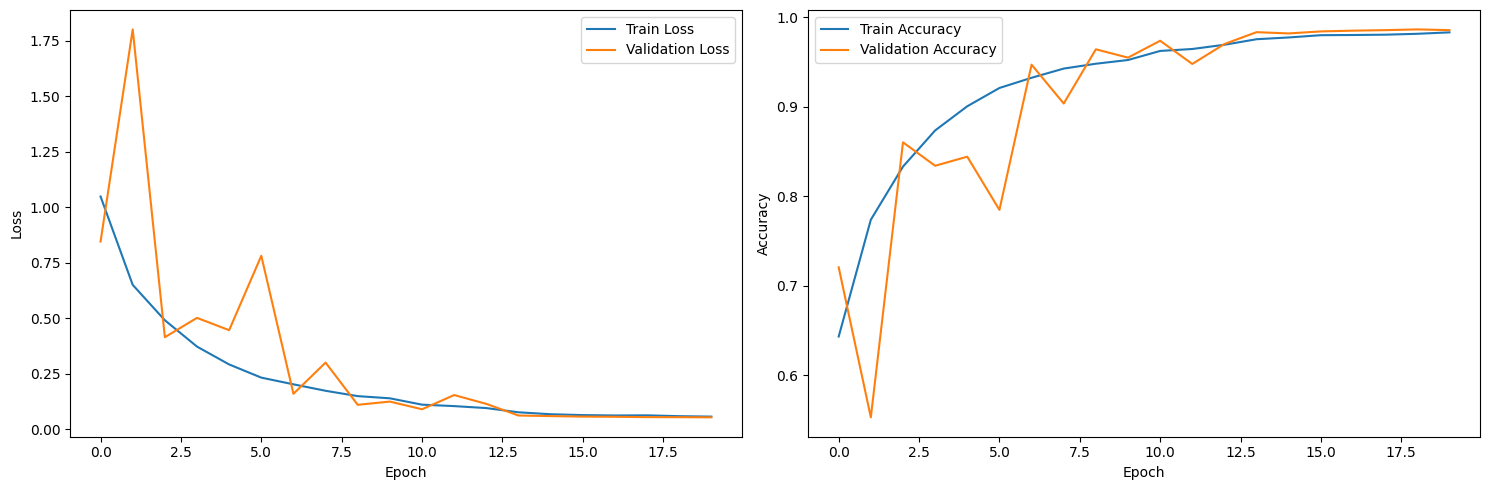

In [ ]:
fig,axes=plt.subplots(1,2,figsize=(15,5))

axes[0].plot(history_3.history['loss'],label='Train Loss')
axes[0].plot(history_3.history['val_loss'],label='Validation Loss')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Loss')
axes[0].legend()

axes[1].plot(history_3.history['accuracy'],label='Train Accuracy')
axes[1].plot(history_3.history['val_accuracy'],label='Validation Accuracy')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Accuracy')
axes[1].legend()

plt.tight_layout()

In [ ]:
model_3.evaluate(test_data)

555/555 [==============================] - 72s 130ms/step - loss: 0.0399 - accuracy: 0.9872


[0.039917439222335815, 0.987162172794342]

In [ ]:
model_3.save('model_3_98.71.keras')

# Model_4

In [17]:
@tf.keras.utils.register_keras_serializable()
class Compact_block(tf.keras.layers.Layer):
  def __init__(self,filters_sq,filters_exp,activation='relu',**kwargs):
    super().__init__(**kwargs)
    self.filters_sq=filters_sq
    self.filters_exp=filters_exp
    self.activation=activation
    self.concat=tf.keras.layers.Concatenate(axis=-1)

    self.layer_1 = tf.keras.layers.Conv2D(filters=self.filters_sq,kernel_size=1,padding='same',activation=self.activation)
    self.layer_2 = tf.keras.layers.Conv2D(filters=self.filters_exp,kernel_size=1,padding='same',activation=self.activation)
    self.layer_3 = tf.keras.layers.Conv2D(filters=self.filters_exp,kernel_size=3,padding='same',activation=self.activation)


  def call(self,inputs):
    x=inputs
    layer_1=self.layer_1(x)
    layer_2=self.layer_2(layer_1)
    layer_3=self.layer_3(layer_1)
    layer_4=self.concat([layer_2,layer_3])
    return layer_4

  def get_config(self):
    config = super().get_config()
    config.update({
        "filters_sq": self.filters_sq,
        "filters_exp": self.filters_exp,
        "activation": self.activation
    })
    return config

In [20]:
inputs=tf.keras.layers.Input(shape=(255,255,3))
in_block_1=Inception_mode(filters=68,strides=2)(inputs)
layer_1=Compact_block(filters_sq=16,filters_exp=64)(in_block_1)
layer_2=Compact_block(filters_sq=16,filters_exp=64)(layer_1)
conv_1=tf.keras.layers.Conv2D(filters=64,kernel_size=3,padding='valid',activation='relu',strides=2)(layer_2)
max_1=tf.keras.layers.MaxPool2D(pool_size=(2,2))(conv_1)
layer_3=Compact_block(filters_sq=64,filters_exp=128)(max_1)
layer_4=Compact_block(filters_sq=64,filters_exp=128)(layer_3)
layer_5=tf.keras.layers.GlobalAveragePooling2D()(layer_4)
outputs=tf.keras.layers.Dense(10,activation='softmax')(layer_5)

model_4=tf.keras.Model(inputs=inputs,outputs=outputs)








model_4.summary()
model_4.compile(optimizer=tf.keras.optimizers.SGD(momentum=0.9,nesterov=True),loss='categorical_crossentropy',metrics=['accuracy'])

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_2 (InputLayer)      │ (None, 255, 255, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ inception_mode_2                │ (None, 128, 128, 204)  │        92,956 │
│ (Inception_mode)                │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ compact_block_4 (Compact_block) │ (None, 128, 128, 128)  │        13,648 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ compact_block_5 (Compact_block) │ (None, 128, 128, 128)  │        12,432 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_38 (Conv2D)              │ (None, 63, 63, 64)     │        73,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 31, 31, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ compact_block_6 (Compact_block) │ (None, 31, 31, 256)    │        86,336 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ compact_block_7 (Compact_block) │ (None, 31, 31, 256)    │        98,624 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 256)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 10)             │         2,570 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 380,358 (1.45 MB)

 Trainable params: 379,950 (1.45 MB)

 Non-trainable params: 408 (1.59 KB)

In [21]:

def lr_schedule_exp(epoch):
  if epoch<7:
    return float(tf.exp(-epoch/10.)*0.01)/3
  else:
    return float(tf.exp(-epoch/10.)*0.01)/4
schedule_4=tf.keras.callbacks.LearningRateScheduler(lr_schedule_exp)
check_point_4=tf.keras.callbacks.ModelCheckpoint('model_4.keras',monitor='val_accuracy',verbose=1,save_best_only=True)

In [22]:
history_4=model_4.fit(train_data,epochs=20,validation_data=(validation_data),callbacks=[schedule_4,check_point_4])

Epoch 1/20
444/444 ━━━━━━━━━━━━━━━━━━━━ 0s 269ms/step - accuracy: 0.2554 - loss: 2.0814
Epoch 1: val_accuracy improved from -inf to 0.42310, saving model to model_4.keras
444/444 ━━━━━━━━━━━━━━━━━━━━ 154s 304ms/step - accuracy: 0.2556 - loss: 2.0809 - val_accuracy: 0.4231 - val_loss: 1.6507 - learning_rate: 0.0033
Epoch 2/20
444/444 ━━━━━━━━━━━━━━━━━━━━ 0s 240ms/step - accuracy: 0.5096 - loss: 1.3742
Epoch 2: val_accuracy improved from 0.42310 to 0.53549, saving model to model_4.keras
444/444 ━━━━━━━━━━━━━━━━━━━━ 169s 263ms/step - accuracy: 0.5097 - loss: 1.3739 - val_accuracy: 0.5355 - val_loss: 1.3656 - learning_rate: 0.0030
Epoch 3/20
444/444 ━━━━━━━━━━━━━━━━━━━━ 0s 239ms/step - accuracy: 0.6668 - loss: 0.9641
Epoch 3: val_accuracy improved from 0.53549 to 0.71014, saving model to model_4.keras
444/444 ━━━━━━━━━━━━━━━━━━━━ 117s 262ms/step - accuracy: 0.6669 - loss: 0.9640 - val_accuracy: 0.7101 - val_loss: 0.8554 - learning_rate: 0.0027
Epoch 4/20
444/444 ━━━━━━━━━━━━━━━━━━━━ 0s 239

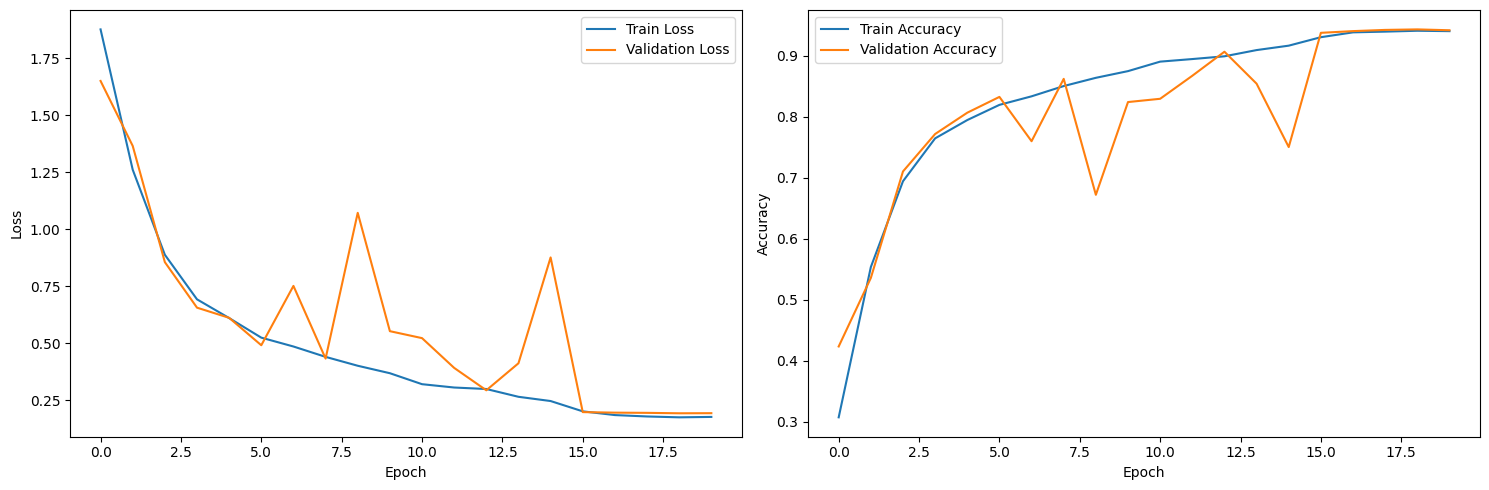

In [23]:
fig,axes=plt.subplots(1,2,figsize=(15,5))

axes[0].plot(history_4.history['loss'],label='Train Loss')
axes[0].plot(history_4.history['val_loss'],label='Validation Loss')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Loss')
axes[0].legend()

axes[1].plot(history_4.history['accuracy'],label='Train Accuracy')
axes[1].plot(history_4.history['val_accuracy'],label='Validation Accuracy')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Accuracy')
axes[1].legend()

plt.tight_layout()

In [24]:
model_4.evaluate(test_data)

139/139 ━━━━━━━━━━━━━━━━━━━━ 14s 99ms/step - accuracy: 0.9397 - loss: 0.2009


[0.19177739322185516, 0.940315306186676]

In [ ]:
model_4.save('model_4.keras')
from google.colab import files
files.download('model_4.keras')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [25]:
inputs=tf.keras.layers.Input(shape=(255,255,3))
in_block_1=Inception_mode(filters=68,strides=2)(inputs)
layer_1=Compact_block(filters_sq=16,filters_exp=64)(in_block_1)
layer_2=Compact_block(filters_sq=16,filters_exp=64)(layer_1)
conv_1=tf.keras.layers.Conv2D(filters=64,kernel_size=3,padding='valid',activation='relu',strides=2)(layer_2)
max_1=tf.keras.layers.MaxPool2D(pool_size=(2,2))(conv_1)
layer_3=Compact_block(filters_sq=64,filters_exp=128)(max_1)
layer_4=Compact_block(filters_sq=64,filters_exp=128)(layer_3)
layer_5=tf.keras.layers.GlobalAveragePooling2D()(layer_4)
outputs=tf.keras.layers.Dense(10,activation='softmax')(layer_5)

model_4_=tf.keras.Model(inputs=inputs,outputs=outputs)








model_4_.summary()
model_4_.compile(optimizer=tf.keras.optimizers.SGD(momentum=0.9,nesterov=True),loss='categorical_crossentropy',metrics=['accuracy'])

Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_3 (InputLayer)      │ (None, 255, 255, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ inception_mode_3                │ (None, 128, 128, 204)  │        92,956 │
│ (Inception_mode)                │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ compact_block_8 (Compact_block) │ (None, 128, 128, 128)  │        13,648 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ compact_block_9 (Compact_block) │ (None, 128, 128, 128)  │        12,432 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_57 (Conv2D)              │ (None, 63, 63, 64)     │        73,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_5 (MaxPooling2D)  │ (None, 31, 31, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ compact_block_10                │ (None, 31, 31, 256)    │        86,336 │
│ (Compact_block)                 │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ compact_block_11                │ (None, 31, 31, 256)    │        98,624 │
│ (Compact_block)                 │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_1      │ (None, 256)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │         2,570 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 380,358 (1.45 MB)

 Trainable params: 379,950 (1.45 MB)

 Non-trainable params: 408 (1.59 KB)

In [26]:

def lr_schedule_exp(epoch):
  if epoch<15:
    return float(tf.exp(-epoch/10.)*0.01)/2
  else:
    return float(tf.exp(-epoch/10.)*0.01)/4
schedule_4=tf.keras.callbacks.LearningRateScheduler(lr_schedule_exp)
check_point_4=tf.keras.callbacks.ModelCheckpoint('model_4_.keras',monitor='val_accuracy',verbose=1,save_best_only=True)

In [27]:
history_4_=model_4_.fit(train_data,epochs=30,validation_data=(validation_data),callbacks=[schedule_4,check_point_4])

Epoch 1/30
444/444 ━━━━━━━━━━━━━━━━━━━━ 0s 246ms/step - accuracy: 0.2444 - loss: 2.0770
Epoch 1: val_accuracy improved from -inf to 0.38507, saving model to model_4_.keras
444/444 ━━━━━━━━━━━━━━━━━━━━ 126s 267ms/step - accuracy: 0.2446 - loss: 2.0764 - val_accuracy: 0.3851 - val_loss: 1.8523 - learning_rate: 0.0050
Epoch 2/30
444/444 ━━━━━━━━━━━━━━━━━━━━ 0s 239ms/step - accuracy: 0.6063 - loss: 1.1244
Epoch 2: val_accuracy improved from 0.38507 to 0.71690, saving model to model_4_.keras
444/444 ━━━━━━━━━━━━━━━━━━━━ 136s 263ms/step - accuracy: 0.6064 - loss: 1.1241 - val_accuracy: 0.7169 - val_loss: 0.8188 - learning_rate: 0.0045
Epoch 3/30
444/444 ━━━━━━━━━━━━━━━━━━━━ 0s 239ms/step - accuracy: 0.7446 - loss: 0.7419
Epoch 3: val_accuracy did not improve from 0.71690
444/444 ━━━━━━━━━━━━━━━━━━━━ 142s 262ms/step - accuracy: 0.7446 - loss: 0.7419 - val_accuracy: 0.6085 - val_loss: 1.1189 - learning_rate: 0.0041
Epoch 4/30
444/444 ━━━━━━━━━━━━━━━━━━━━ 0s 239ms/step - accuracy: 0.8027 - loss

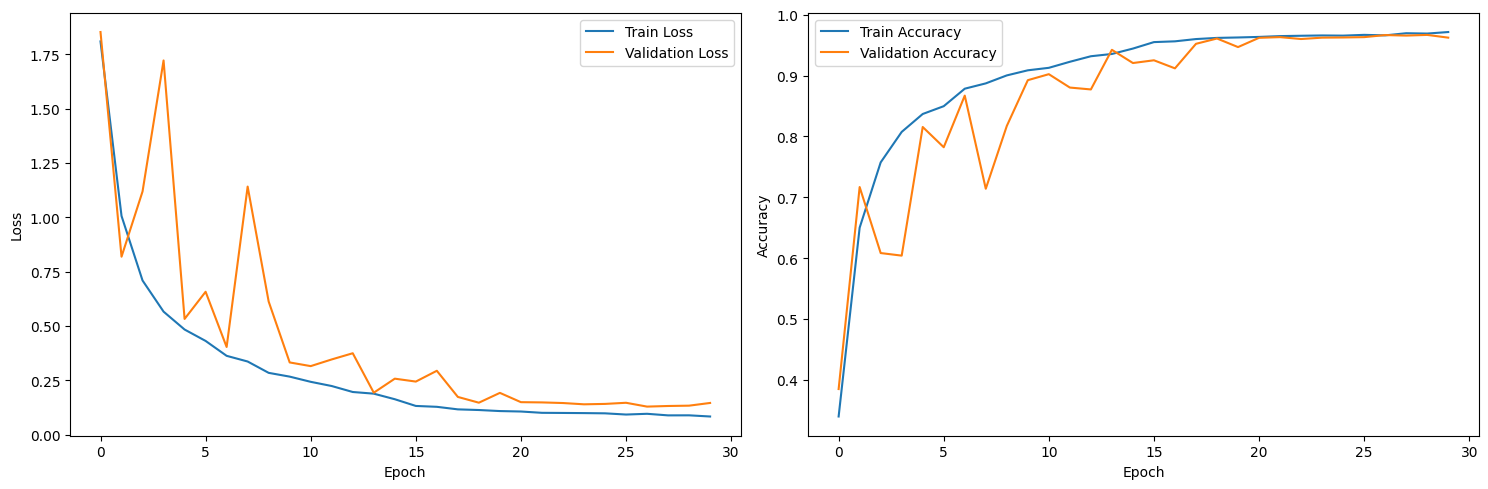

In [28]:
fig,axes=plt.subplots(1,2,figsize=(15,5))

axes[0].plot(history_4_.history['loss'],label='Train Loss')
axes[0].plot(history_4_.history['val_loss'],label='Validation Loss')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Loss')
axes[0].legend()

axes[1].plot(history_4_.history['accuracy'],label='Train Accuracy')
axes[1].plot(history_4_.history['val_accuracy'],label='Validation Accuracy')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Accuracy')
axes[1].legend()

plt.tight_layout()

In [29]:
model_4_.evaluate(test_data)

139/139 ━━━━━━━━━━━━━━━━━━━━ 10s 71ms/step - accuracy: 0.9586 - loss: 0.1281


[0.11948186159133911, 0.9610360264778137]

# Transfer Learning Models

* ResNet50

In [ ]:

base_model = tf.keras.applications.ResNet50(weights="imagenet", include_top=False, input_shape=(255, 255, 3))
for layer in base_model.layers[:len(base_model.layers)-int(len(base_model.layers)*0.8)]:
  layer.trainable=False
inputs=tf.keras.layers.Input(shape=(255,255,3))
x = base_model(inputs)



x = tf.keras.layers.GlobalAveragePooling2D()(x)
x = tf.keras.layers.Dense(500, activation="relu")(x)
x = tf.keras.layers.Dropout(0.2)(x)
output = tf.keras.layers.Dense(10, activation="softmax")(x)
Res_model = tf.keras.Model(inputs=inputs, outputs=output)
Res_model.summary()

Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_3 (InputLayer)      │ (None, 255, 255, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ resnet50 (Functional)           │ (None, 8, 8, 2048)     │    23,587,712 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_1      │ (None, 2048)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 500)            │     1,024,500 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 500)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 10)             │         5,010 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 24,617,222 (93.91 MB)

 Trainable params: 24,354,438 (92.90 MB)

 Non-trainable params: 262,784 (1.00 MB)

In [ ]:

def lr_schedule_exp(epoch):
    return float(tf.exp(-epoch/10.)*0.01)/3
schedule_res=tf.keras.callbacks.LearningRateScheduler(lr_schedule_exp)
check_point_res=tf.keras.callbacks.ModelCheckpoint('model_res.keras',monitor='val_accuracy',verbose=1,save_best_only=True)

In [ ]:
Res_model.compile(loss='categorical_crossentropy',optimizer=tf.keras.optimizers.SGD(momentum=0.9,
                                                                                    nesterov=True),metrics=['accuracy'])

In [ ]:
res_history=Res_model.fit(train_data,epochs=20,validation_data=validation_data,callbacks=[schedule_res,check_point_res])

Epoch 1/20
444/444 ━━━━━━━━━━━━━━━━━━━━ 0s 310ms/step - accuracy: 0.5988 - loss: 1.1720
Epoch 1: val_accuracy improved from -inf to 0.29831, saving model to model_res.keras
444/444 ━━━━━━━━━━━━━━━━━━━━ 202s 364ms/step - accuracy: 0.5990 - loss: 1.1712 - val_accuracy: 0.2983 - val_loss: 2.3503 - learning_rate: 0.0033
Epoch 2/20
444/444 ━━━━━━━━━━━━━━━━━━━━ 0s 267ms/step - accuracy: 0.8607 - loss: 0.3986
Epoch 2: val_accuracy did not improve from 0.29831
444/444 ━━━━━━━━━━━━━━━━━━━━ 148s 291ms/step - accuracy: 0.8607 - loss: 0.3985 - val_accuracy: 0.2780 - val_loss: 4.9134 - learning_rate: 0.0030
Epoch 3/20
444/444 ━━━━━━━━━━━━━━━━━━━━ 0s 272ms/step - accuracy: 0.9345 - loss: 0.1845
Epoch 3: val_accuracy improved from 0.29831 to 0.41662, saving model to model_res.keras
444/444 ━━━━━━━━━━━━━━━━━━━━ 133s 300ms/step - accuracy: 0.9345 - loss: 0.1845 - val_accuracy: 0.4166 - val_loss: 2.9528 - learning_rate: 0.0027
Epoch 4/20
444/444 ━━━━━━━━━━━━━━━━━━━━ 0s 274ms/step - accuracy: 0.9667 - lo

In [ ]:
Res_model.evaluate(test_data)

139/139 ━━━━━━━━━━━━━━━━━━━━ 18s 128ms/step - accuracy: 0.9628 - loss: 0.1336


[0.14011608064174652, 0.9619369506835938]

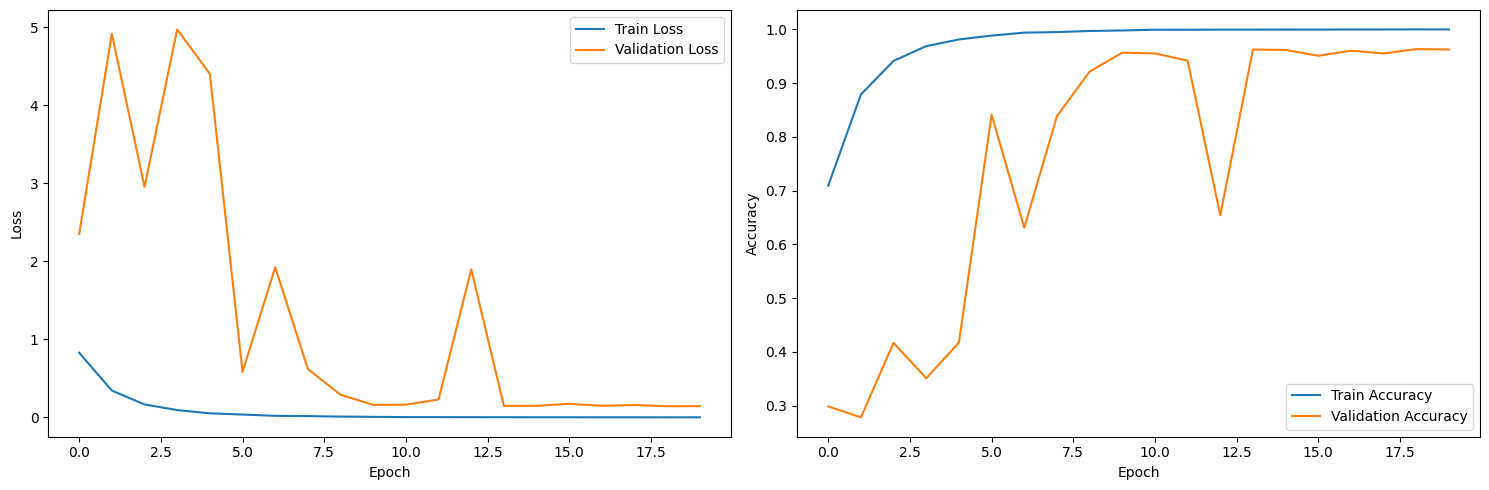

In [ ]:
fig,axes=plt.subplots(1,2,figsize=(15,5))

axes[0].plot(res_history.history['loss'],label='Train Loss')
axes[0].plot(res_history.history['val_loss'],label='Validation Loss')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Loss')
axes[0].legend()

axes[1].plot(res_history.history['accuracy'],label='Train Accuracy')
axes[1].plot(res_history.history['val_accuracy'],label='Validation Accuracy')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Accuracy')
axes[1].legend()

plt.tight_layout()

* InceptionV3

In [ ]:
base_model_2=tf.keras.applications.InceptionV3(weights='imagenet',include_top=False, input_shape=(255, 255, 3))
for layer in base_model_2.layers[::len(base_model_2.layers)-int(len(base_model_2.layers)*0.8)]:
  layer.trainable=False

inputs=tf.keras.layers.Input(shape=(255,255,3))

x = base_model_2(inputs)



x = tf.keras.layers.GlobalAveragePooling2D()(x)
x = tf.keras.layers.Dense(500, activation="relu")(x)
x = tf.keras.layers.Dropout(0.2)(x)
output = tf.keras.layers.Dense(10, activation="softmax")(x)
Ins_model = tf.keras.Model(inputs=inputs, outputs=output)
Ins_model.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_2 (InputLayer)      │ (None, 255, 255, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ inception_v3 (Functional)       │ (None, 6, 6, 2048)     │    21,802,784 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 2048)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 500)            │     1,024,500 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 500)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │         5,010 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 22,832,294 (87.10 MB)

 Trainable params: 22,305,958 (85.09 MB)

 Non-trainable params: 526,336 (2.01 MB)

In [ ]:
def lr_schedule_exp(epoch):
    return float(tf.exp(-epoch/10.)*0.01)/3
schedule_In=tf.keras.callbacks.LearningRateScheduler(lr_schedule_exp)
check_point_In=tf.keras.callbacks.ModelCheckpoint('model_res.keras',monitor='val_accuracy',verbose=1,save_best_only=True)

In [ ]:
Ins_model.compile(loss='categorical_crossentropy',optimizer=tf.keras.optimizers.SGD(momentum=0.9,
                                                                                    nesterov=True),metrics=['accuracy'])

In [ ]:
in_history=Ins_model.fit(train_data,epochs=20,validation_data=validation_data,callbacks=[schedule_In,check_point_In])

Epoch 1/20
444/444 ━━━━━━━━━━━━━━━━━━━━ 0s 358ms/step - accuracy: 0.7467 - loss: 0.7604
Epoch 1: val_accuracy improved from -inf to 0.94282, saving model to model_res.keras
444/444 ━━━━━━━━━━━━━━━━━━━━ 253s 415ms/step - accuracy: 0.7470 - loss: 0.7596 - val_accuracy: 0.9428 - val_loss: 0.1637 - learning_rate: 0.0033
Epoch 2/20
444/444 ━━━━━━━━━━━━━━━━━━━━ 0s 281ms/step - accuracy: 0.9736 - loss: 0.0801
Epoch 2: val_accuracy improved from 0.94282 to 0.98028, saving model to model_res.keras
444/444 ━━━━━━━━━━━━━━━━━━━━ 135s 303ms/step - accuracy: 0.9736 - loss: 0.0800 - val_accuracy: 0.9803 - val_loss: 0.0584 - learning_rate: 0.0030
Epoch 3/20
444/444 ━━━━━━━━━━━━━━━━━━━━ 0s 280ms/step - accuracy: 0.9873 - loss: 0.0402
Epoch 3: val_accuracy improved from 0.98028 to 0.98563, saving model to model_res.keras
444/444 ━━━━━━━━━━━━━━━━━━━━ 142s 303ms/step - accuracy: 0.9873 - loss: 0.0402 - val_accuracy: 0.9856 - val_loss: 0.0387 - learning_rate: 0.0027
Epoch 4/20
444/444 ━━━━━━━━━━━━━━━━━━━━ 

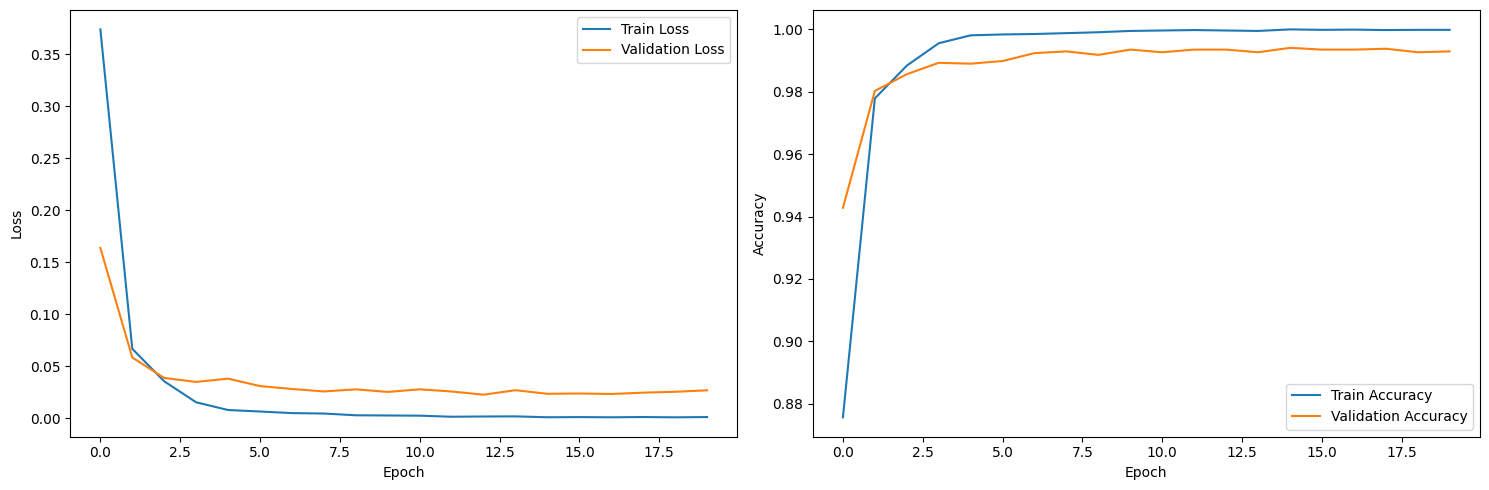

In [ ]:
fig,axes=plt.subplots(1,2,figsize=(15,5))

axes[0].plot(in_history.history['loss'],label='Train Loss')
axes[0].plot(in_history.history['val_loss'],label='Validation Loss')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Loss')
axes[0].legend()

axes[1].plot(in_history.history['accuracy'],label='Train Accuracy')
axes[1].plot(in_history.history['val_accuracy'],label='Validation Accuracy')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Accuracy')
axes[1].legend()

plt.tight_layout()

In [ ]:
Ins_model.evaluate(test_data)

139/139 ━━━━━━━━━━━━━━━━━━━━ 21s 153ms/step - accuracy: 0.9947 - loss: 0.0207


[0.026401884853839874, 0.9932432174682617]